In [12]:
import pandas as pd
weather = pd.read_csv('3B_LosAngeles_monthly_avg.csv')
anxiety = pd.read_csv('anxiety_only_data.csv')

weather['time_lst'] = pd.to_datetime(weather['time_lst']) #get rid of the montly indexing from v1, was just for display
weather = weather.set_index('time_lst')

anxiety = anxiety[anxiety['demographics_type'] == 'Age']
# anxiety = anxiety.drop(columns =['demographics_values'])
anxiety = anxiety[anxiety['demographics_values'] != 'All']

anxiety['month_end'] = pd.to_datetime(anxiety['month_end'])
anxiety = anxiety.set_index('month_end')

#anxiety.head
weather.head

<bound method NDFrame.head of                   tas             ps       hurs   sfcWind        rsds  \
time_lst                                                                
2001-01-31  13.084735  101041.541449  59.741414  1.986968  135.670841   
2001-02-28  16.750064  101266.170399  49.428195  1.529056  163.076378   
2001-03-31  15.920363  100898.301394  64.960349  1.648634  199.345206   
2001-04-30  14.854306  100695.213555  77.196968  1.861563  265.564120   
2001-05-31  16.467725  100627.715873  82.297143  1.678022  273.064116   
...               ...            ...        ...       ...         ...   
2020-08-31  19.929217  100732.086344  82.738523  1.804708  249.879865   
2020-09-30  19.492538  100333.567991  81.521157  1.744176  228.081499   
2020-10-31  19.567662  100669.181065  56.505152  1.548965  184.564516   
2020-11-30  16.215588  100729.876416  72.078580  1.310143  116.139640   
2020-12-31  14.314113  101045.006186  60.922043  1.518769  118.813172   

                 hus

In [2]:
# Now open source GitHub code

# Install libraries and such

import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
!pip install seaborn --upgrade
import seaborn as sns
import matplotlib.pyplot as plt

# !pip uninstall scikit-learn -y
# !pip install scikit-learn

from sklearn.linear_model import Ridge

Requirement already up-to-date: seaborn in /Users/norahocallaghan/opt/anaconda3/lib/python3.8/site-packages (0.13.2)


In [14]:
# BAYES RIDGE REGRESSION for ALL WEATHER variables 

from sklearn.linear_model import BayesianRidge
import pandas as pd

rr = BayesianRidge()

climate_vars = ['tas', 'ps', 'hurs', 'sfcWind', 'rsds', 'huss']

def backtest(weather, model, predictors, start=24, step=1): #starts at month 24, goes 1 month at a time
    all_predictions_weather = []
    
    for i in range(start, weather.shape[0], step):
        # Train on all months before i
        train = weather.iloc[:i, :]
        # Test on month i
        test = weather.iloc[i:(i + step)]
        
        model.fit(train[predictors], train["target"])
        preds = model.predict(test[predictors])
        preds = pd.Series(preds, index=test.index)
        
        combined = pd.concat([test["target"], preds], axis=1)
        combined.columns = ["actual", "prediction"]
        combined["diff"] = (combined["prediction"] - combined["actual"]).abs()
        #print(combined)
        
        all_predictions_weather.append(combined)
    
    return pd.concat(all_predictions_weather)

all_results_weather = {}

for var in climate_vars:
    # Fresh copy of weather each time so changes to one variable don't carry
    weather_copy = weather.copy()
    
    # Target is the value for next month
    weather_copy["target"] = weather_copy[var].shift(-1)
    weather_copy = weather_copy.dropna(subset=["target"])

    # Exclude non-variable columns and use all 5 climate variables to predict each variable
    predictors = weather_copy.columns[~weather_copy.columns.isin(["target", "time_lst", "month"])]

    all_results_weather[var] = backtest(weather_copy, rr, predictors)
    weather_copy = weather.copy()
        
    # Target is the value for next month
    weather_copy["target"] = weather_copy[var].shift(-1)
    weather_copy = weather_copy.dropna(subset=["target"])
    
    # Exclude non-variable columns and use all 5 climate variables to predict each variable
    predictors = [v for v in climate_vars if v != var]
    
    all_results_weather[var] = backtest(weather_copy, rr, predictors)
    
    results = all_results_weather[var]
    mae = results["diff"].mean()
    data_range = weather[var].max() - weather[var].min()
    pct = (mae / data_range) * 100
    
    print(f"{var}: MAE = {mae:.2f}, MAE% = {pct:.2f}%")

tas: MAE = 1.34, MAE% = 11.64%
ps: MAE = 112.11, MAE% = 9.40%
hurs: MAE = 6.28, MAE% = 12.05%
sfcWind: MAE = 0.14, MAE% = 13.18%
rsds: MAE = 46.81, MAE% = 19.21%
huss: MAE = 3.05, MAE% = 21.26%


In [4]:
# Pivot so each age group in anxiety becomes a column,
# then have multiple variables per row (month) and can use same weather BRR architecture
anxiety_pivot = anxiety.pivot_table(
    index='month_end', 
    columns='demographics_values', 
    values='rate_per_100000_visits'
)
anxiety_pivot.columns.name = None

print(anxiety_pivot.head())

            12-17 years  18-34 years  35-64 years  65+ years
month_end                                                   
2019-01-01         2115         2941         3268       2408
2019-02-01         2112         3097         3345       2496
2019-03-01         2158         3190         3484       2563
2019-04-01         2267         3266         3520       2593
2019-05-01         2228         3287         3522       2602


In [5]:
from sklearn.linear_model import BayesianRidge
import pandas as pd

rr = BayesianRidge()
anxiety_vars = ['12-17 years', '18-34 years', '35-64 years', '65+ years']

def backtest(data, model, predictors, start=24, step=1):
    all_predictions_anxiety = []
    
    for i in range(start, data.shape[0], step):
        # Train on all months before i
        train = data.iloc[:i, :]
        # Test on month i
        test = data.iloc[i:(i + step)]
        
        model.fit(train[predictors], train["target"])
        preds = model.predict(test[predictors])
        preds = pd.Series(preds, index=test.index)
        
        combined = pd.concat([test["target"], preds], axis=1)
        combined.columns = ["actual", "prediction"]
        combined["diff"] = (combined["prediction"] - combined["actual"]).abs()
        
        all_predictions_anxiety.append(combined)
    
    return pd.concat(all_predictions_anxiety)

all_results_anxiety = {}
for var in anxiety_vars:
    anxiety_vars_copy = anxiety_pivot.copy()
    anxiety_vars_copy["target"] = anxiety_vars_copy[var].shift(-1)
    anxiety_vars_copy = anxiety_vars_copy.dropna(subset=["target"])
    
    # Use all other age groups as predictors
    predictors = [v for v in anxiety_vars if v != var]
    
    all_results_anxiety[var] = backtest(anxiety_vars_copy, rr, predictors)
    mae = all_results_anxiety[var]["diff"].mean()
    data_range = anxiety_pivot[var].max() - anxiety_pivot[var].min()
    pct = (mae / data_range) * 100
    print(f"{var}: MAE = {mae:.2f}, MAE% = {pct:.2f}%")

12-17 years: MAE = 196.66, MAE% = 11.05%
18-34 years: MAE = 117.38, MAE% = 6.05%
35-64 years: MAE = 147.78, MAE% = 8.79%
65+ years: MAE = 112.69, MAE% = 13.24%


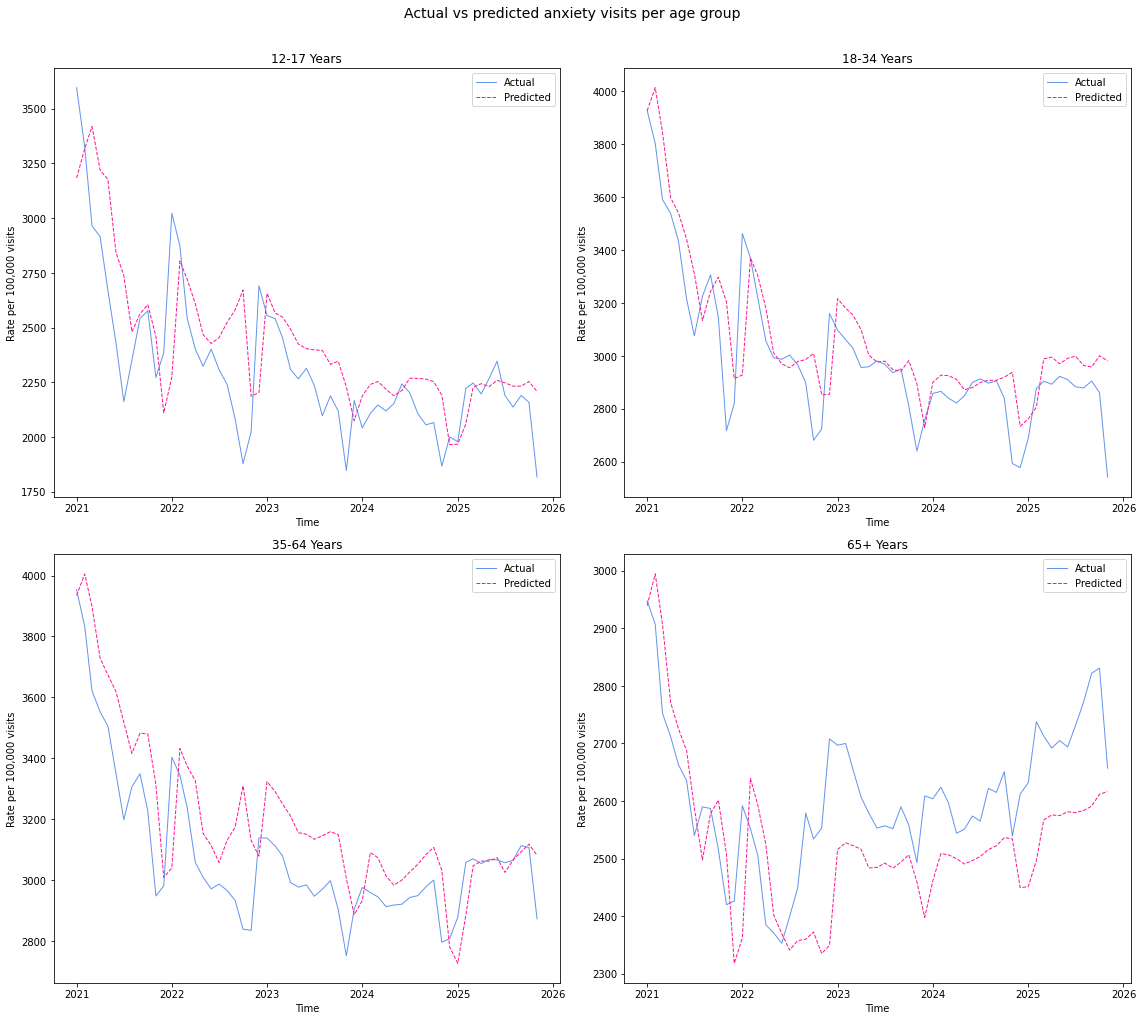

In [18]:
# plot predicted versus actual values for anxiety ages

fig, axs = plt.subplots(2, 2, figsize=(16, 14))
axs = axs.flatten()

var_labels = {
    '12-17 years': '12-17 Years',
    '18-34 years': '18-34 Years',
    '35-64 years': '35-64 Years',
    '65+ years': '65+ Years'
}

for i, var in enumerate(anxiety_vars):
    ax = axs[i]
    results = all_results_anxiety[var]
    
    x = results.index.to_numpy()
    
    ax.plot(x, results["actual"].values, 
            label="Actual", color="cornflowerblue", linewidth=1)
    ax.plot(x, results["prediction"].values, 
            label="Predicted", color="deeppink", linewidth=1, linestyle="--")
    
    ax.set_title(var_labels[var], fontsize=12)
    ax.set_xlabel("Time")
    ax.set_ylabel("Rate per 100,000 visits")
    ax.legend()

plt.suptitle("Actual vs predicted anxiety visits per age group", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [7]:
# Convert both indices to year-month period
weather.index = weather.index.to_period('M')
anxiety_pivot.index = anxiety_pivot.index.to_period('M')

# Now join on year-month
combined = weather.join(anxiety_pivot, how='inner') #inner only keeps data with dates in common
print(combined.shape)
print(combined.head())

print(f"Weather date range: {weather.index.min()} to {weather.index.max()}")
print(f"Anxiety date range: {anxiety_pivot.index.min()} to {anxiety_pivot.index.max()}")
print(f"Combined rows: {combined.shape[0]}")
print(f"Date range: {combined.index.min()} to {combined.index.max()}")

(24, 10)
               tas             ps       hurs   sfcWind        rsds       huss  \
2019-01  13.223809  101026.572560  58.742263  1.639905  140.562822  15.581811   
2019-02  12.603288  101045.467469  68.242198  1.959942  187.434674   5.670902   
2019-03  16.768950  100924.632563  63.872536  1.643952  201.272177   7.294091   
2019-04  16.944101  100858.729084  69.749963  2.012532  251.582639  13.971374   
2019-05  17.187164  100643.504134  73.408406  2.100346  295.847000   6.211674   

         12-17 years  18-34 years  35-64 years  65+ years  
2019-01         2115         2941         3268       2408  
2019-02         2112         3097         3345       2496  
2019-03         2158         3190         3484       2563  
2019-04         2267         3266         3520       2593  
2019-05         2228         3287         3522       2602  
Weather date range: 2001-01 to 2020-12
Anxiety date range: 2019-01 to 2025-12
Combined rows: 24
Date range: 2019-01 to 2020-12


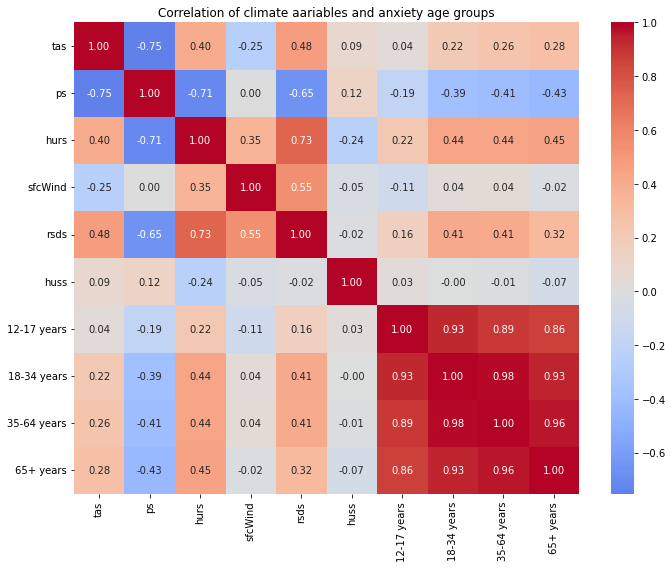

In [19]:
# Check correlation

plt.figure(figsize=(10, 8))
sns.heatmap(combined.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation of climate aariables and anxiety age groups")
plt.tight_layout()
plt.show()

In [9]:
# Multioutput BRR for predicting anxiety based on weather for all age groups

from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import BayesianRidge
import pandas as pd

# will use the combined data from earlier cell

multi_rr = MultiOutputRegressor(BayesianRidge())

anxiety_vars = ['12-17 years', '18-34 years', '35-64 years', '65+ years']

def backtest_multitask(data, model, predictors, targets, start=2, step=1):
    # Starting @ month 2
    
    all_predictions = []
    
    for i in range(start, data.shape[0], step):
        train = data.iloc[:i, :]
        test = data.iloc[i:(i + step)]
        
        model.fit(train[predictors], train[targets])
        preds = model.predict(test[predictors])
        preds = pd.DataFrame(preds, index=test.index, columns=targets)
        
        combined = pd.concat([test[targets], preds], axis=1)
        combined.columns = [f"actual_{t}" for t in targets] + [f"pred_{t}" for t in targets]
        
        all_predictions.append(combined)
    
    return pd.concat(all_predictions)

# Climate variables as predictors, age groups as targets
predictors = climate_vars  # ['tas', 'ps', 'hurs', 'sfcWind', 'rsds', 'huss']
targets = anxiety_vars     # ['12-17 years', '18-34 years', '35-64 years', '65+ years']

# Shift targets by 1 month to predict the next month
combined_copy = combined.copy()
for t in targets:
    combined_copy[t] = combined_copy[t].shift(-1)
combined_copy = combined_copy.dropna()

results_multitask = backtest_multitask(combined_copy, multi_rr, predictors, targets)

# MAE for each age group
for var in targets:
    mae = (results_multitask[f"actual_{var}"] - results_multitask[f"pred_{var}"]).abs().mean()
    data_range = combined[var].max() - combined[var].min()
    pct = (mae / data_range) * 100
    print(f"{var}: MAE = {mae:.2f}, MAE% = {pct:.2f}%")

12-17 years: MAE = 375.41, MAE% = 24.57%
18-34 years: MAE = 276.22, MAE% = 17.91%
35-64 years: MAE = 231.40, MAE% = 19.83%
65+ years: MAE = 177.32, MAE% = 22.28%


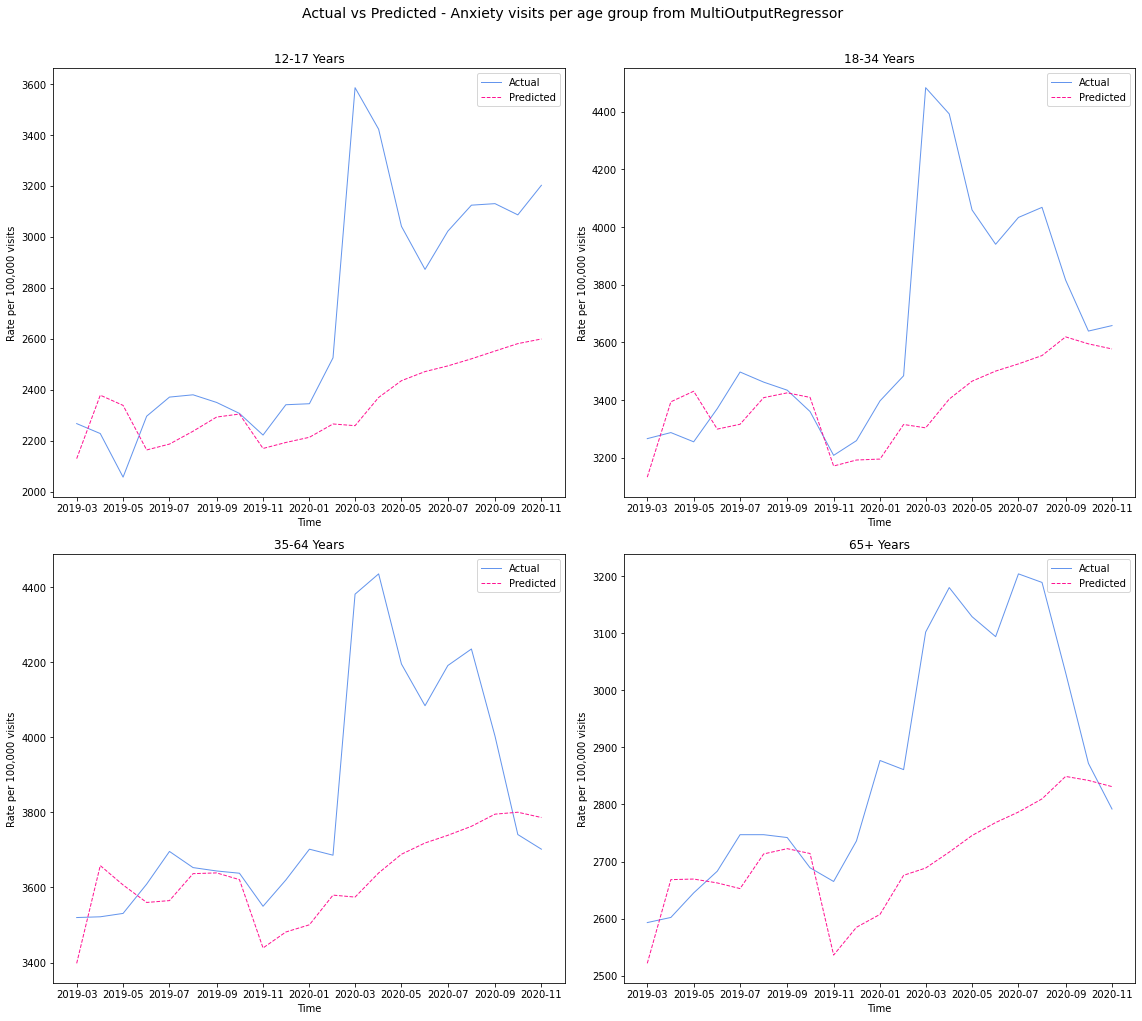

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(16, 14))
axs = axs.flatten()
var_labels = {
    '12-17 years': '12-17 Years',
    '18-34 years': '18-34 Years',
    '35-64 years': '35-64 Years',
    '65+ years': '65+ Years'
}
for i, var in enumerate(anxiety_vars):
    ax = axs[i]
    
    x = results_multitask.index.to_timestamp().to_numpy()
    
    ax.plot(x, results_multitask[f"actual_{var}"].values, 
            label="Actual", color="cornflowerblue", linewidth=1)
    ax.plot(x, results_multitask[f"pred_{var}"].values, 
            label="Predicted", color="deeppink", linewidth=1, linestyle="--")
    
    ax.set_title(var_labels[var], fontsize=12)
    ax.set_xlabel("Time")
    ax.set_ylabel("Rate per 100,000 visits")
    ax.legend()

plt.suptitle("Actual vs predicted anxiety visits per age group from MultiOutputRegressor", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()